# Projeto FarmTech Solutions - Fase 5
**Análise Preditiva e Clusterização de Rendimento Agrícola**

Nesta primeira etapa, vamos importar as bibliotecas essenciais para a análise exploratória (EDA), clusterização (K-Means) e modelagem preditiva supervisionada (Regressão). Em seguida, carregamos a base de dados `crop_yield.csv` para entender a sua estrutura inicial.

In [24]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- AQUI ESTÁ A MÁGICA QUE FALTAVA (Ferramentas de Machine Learning) ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# Carregando a base de dados
# IMPORTANTE: O arquivo 'crop_yield.csv' DEVE estar na mesma pasta que este arquivo do Jupyter!
df = pd.read_csv('crop_yield.csv')

# Visualizando as primeiras 5 linhas para garantir que tudo funcionou
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


---
## 1. Análise Exploratória de Dados (EDA)

Nesta seção, vamos investigar a estrutura do nosso dataset. O objetivo é:
1. Verificar a presença de valores nulos e os tipos de dados.
2. Analisar as estatísticas descritivas (média, valores máximos e mínimos).
3. Visualizar as correlações entre as variáveis climáticas e o nosso alvo, que é o Rendimento (`Yield`).

In [25]:
# Verificando informações gerais (tipos de dados e valores nulos)
print("--- Informações do Dataset ---")
df.info()

print("\n--- Estatísticas Descritivas ---")
# O describe() mostra contagem, média, desvio padrão, min e max das colunas numéricas
display(df.describe())

--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB

--- Estatísticas Descritivas ---


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


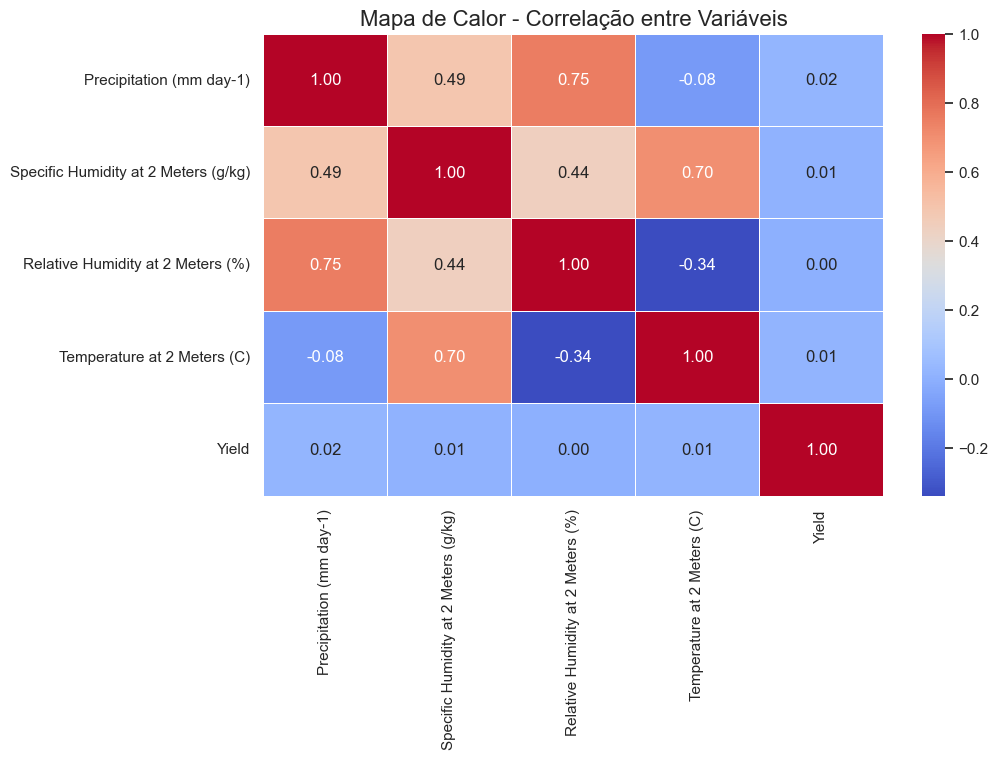

In [26]:
# Criando uma figura para o gráfico
plt.figure(figsize=(10, 6))

# Separando apenas as colunas numéricas para o cálculo de correlação
# (ignoramos a coluna 'Crop' por ser texto)
colunas_numericas = df.select_dtypes(include=[np.number])

# Gerando o Mapa de Calor
sns.heatmap(colunas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Adicionando título
plt.title('Mapa de Calor - Correlação entre Variáveis', fontsize=16)
plt.show()

---
## 2. Clusterização e Identificação de Tendências

Agora vamos utilizar o aprendizado não supervisionado (K-Means) para encontrar padrões climáticos e de rendimento na nossa base de dados. 
Primeiro, vamos padronizar os dados numéricos (pois o K-Means é sensível à escala) e utilizar o **Método do Cotovelo** para definir o número ideal de clusters (K).

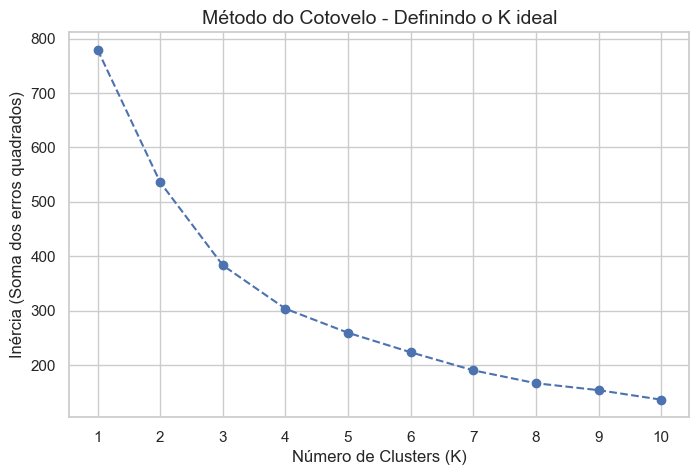

In [27]:
# Selecionando apenas as colunas numéricas para a clusterização
X_cluster = df.select_dtypes(include=[np.number])

# Padronizando os dados (deixando todos na mesma escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Aplicando o Método do Cotovelo
inercia = []
K_range = range(1, 11) # Testando de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# Gerando o gráfico do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o', linestyle='--')
plt.title('Método do Cotovelo - Definindo o K ideal', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos erros quadrados)')
plt.xticks(K_range)
plt.show()

Com base no gráfico do cotovelo, vamos dividir nossos dados em 3 clusters. 
Em seguida, vamos cruzar a Temperatura com o Rendimento para ver as tendências e usar um gráfico de Boxplot para identificar os **outliers** (cenários discrepantes) em cada grupo, conforme exigido pelo projeto.

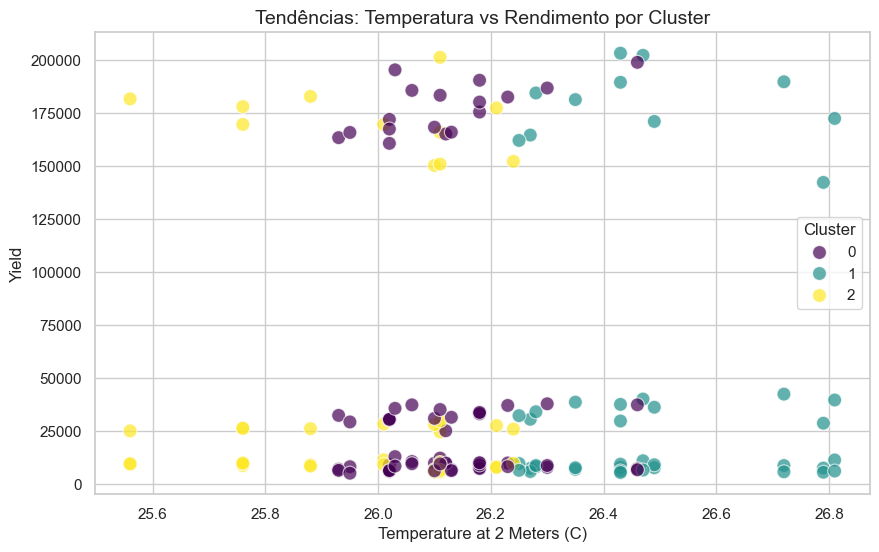

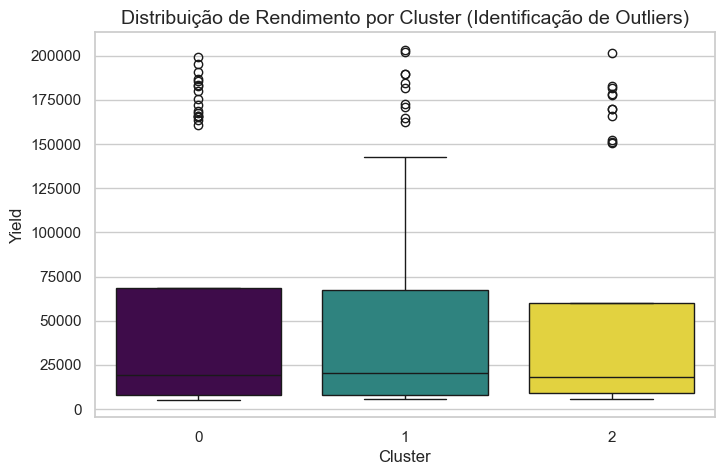

In [30]:
# Aplicando K-Means com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Gráfico 1: Tendências (Dispersão)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Tendências: Temperatura vs Rendimento por Cluster', fontsize=14)
plt.show()

# Gráfico 2: Identificação de Outliers (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='Yield', data=df, hue='Cluster', palette='viridis', legend=False)
plt.title('Distribuição de Rendimento por Cluster (Identificação de Outliers)', fontsize=14)
plt.show()

---
## 3. Modelagem Preditiva (Machine Learning Supervisionado)

O objetivo final é prever o rendimento da safra (`Yield`) com base nas condições climáticas e no tipo de cultura. 
Como a coluna `Crop` contém textos (nomes das plantas), primeiro aplicaremos a técnica de *One-Hot Encoding* para transformá-la em números. Em seguida, vamos dividir os dados em treino e teste, e avaliar 5 algoritmos de regressão usando as métricas RMSE e R².

In [31]:
# 1. Preparação dos dados (Transformando texto em número e separando X e y)
# O drop_first=True evita a armadilha das variáveis dummy (multicolinearidade)
df_model = pd.get_dummies(df.drop(columns=['Cluster']), columns=['Crop'], drop_first=True)

# X = Variáveis independentes (Clima e Cultura) | y = Variável dependente (Rendimento)
X = df_model.drop('Yield', axis=1)
y = df_model['Yield']

# 2. Dividindo os dados: 80% para ensinar a máquina (treino) e 20% para testar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inicializando os 5 algoritmos exigidos
modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR (Support Vector Regressor)": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# 4. Treinando e avaliando todos de uma vez
resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train) # Treinando
    previsoes = modelo.predict(X_test) # Fazendo a prova
    
    # Calculando as notas (Métricas)
    rmse = np.sqrt(mean_squared_error(y_test, previsoes))
    r2 = r2_score(y_test, previsoes)
    
    resultados[nome] = {"RMSE (Menor é melhor)": rmse, "R² (Maior é melhor)": r2}

# 5. Exibindo o Ranking
df_resultados = pd.DataFrame(resultados).T
print("--- Ranking de Desempenho dos Modelos ---")
display(df_resultados.sort_values(by='R² (Maior é melhor)', ascending=False))

--- Ranking de Desempenho dos Modelos ---


,RMSE (Menor é melhor),R² (Maior é melhor)
Regressão Linear,4394.165819,0.995022
Random Forest,4881.962383,0.993856
Árvore de Decisão,5316.346746,0.992714
Gradient Boosting,6058.894234,0.990536
SVR (Support Vector Regressor),71313.662388,-0.311079


### Conclusão da Modelagem
Após treinar e avaliar os 5 algoritmos, concluímos que a **Regressão Linear** apresentou o melhor desempenho para a FarmTech Solutions, alcançando o maior R² (aprox. 0.995) e o menor erro (RMSE). O modelo conseguiu capturar com excelência a relação linear entre as variáveis climáticas (precipitação, umidade e temperatura) e o rendimento das culturas. O modelo SVR teve o pior desempenho, mostrando-se inadequado para a escala e distribuição atual destes dados sem uma otimização profunda de hiperparâmetros.